#  Benchmark de Modelos de Previsão

## 1. Objetivo

Avaliar diferentes algoritmos de Machine Learning para previsão de demanda, comparando desempenho e capacidade preditiva.

Os modelos serão avaliados utilizando métricas de regressão e comparados com o baseline desenvolvido anteriormente.

O objetivo é identificar o modelo mais adequado para suporte à tomada de decisão em estoque e supply chain.

## 2. Importação 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.metrics import mean_absolute_percentage_error

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from IPython.display import Markdown
from IPython.core.display import HTML
import math

import glob
import warnings
warnings.filterwarnings('ignore')

## 3. Configuração Inicial

In [2]:
# Cor principal do projeto
PRIMARY_COLOR = "#50e550"
SECONDARY_COLORS = sns.light_palette(PRIMARY_COLOR, n_colors=5)

# Estilo geral
sns.set_theme(style="whitegrid")

# Tamanho padrão
plt.rcParams['figure.figsize'] = (10, 6)

# Fonte
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## 4. Carregamento dos Dados

In [3]:
df = pd.read_parquet('../data/processed/df_features.parquet')

df.head()

,product_id,date,sales,day_of_week,day,month,year,week_of_year,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,rolling_std_7
133,008cff0e5792219fae03e570f980b330,2018-07-18,2,2,18,7,2018,29,1.0,2.0,1.0,1.142857,1.142857,0.377964
134,008cff0e5792219fae03e570f980b330,2018-07-20,1,4,20,7,2018,29,2.0,1.0,1.0,1.142857,1.214286,0.377964
135,008cff0e5792219fae03e570f980b330,2018-08-01,1,2,1,8,2018,31,1.0,1.0,1.0,1.142857,1.214286,0.377964
136,008cff0e5792219fae03e570f980b330,2018-08-13,1,0,13,8,2018,33,1.0,1.0,1.0,1.142857,1.214286,0.377964
137,008cff0e5792219fae03e570f980b330,2018-08-20,1,0,20,8,2018,34,1.0,1.0,1.0,1.142857,1.214286,0.377964


## 5. Verificação Inicial

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 14470 entries, 133 to 89051
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   product_id       14470 non-null  str           
 1   date             14470 non-null  datetime64[ms]
 2   sales            14470 non-null  int64         
 3   day_of_week      14470 non-null  int32         
 4   day              14470 non-null  int32         
 5   month            14470 non-null  int32         
 6   year             14470 non-null  int32         
 7   week_of_year     14470 non-null  UInt32        
 8   lag_1            14470 non-null  float64       
 9   lag_7            14470 non-null  float64       
 10  lag_14           14470 non-null  float64       
 11  rolling_mean_7   14470 non-null  float64       
 12  rolling_mean_14  14470 non-null  float64       
 13  rolling_std_7    14470 non-null  float64       
dtypes: UInt32(1), datetime64[ms](1), float64(6), int32(4

## 6. Ordenação Temporal

In [5]:
df = df.sort_values('date')

## 7. Separação Treino/Teste

In [6]:
split_date = df['date'].quantile(0.80)

train = df[df['date'] <= split_date]

test = df[df['date'] > split_date]

print(train.shape)
print(test.shape)

(11604, 14)
(2866, 14)


## 8. Seleção de Features

In [7]:
features = [
    'day_of_week',
    'month',
    'lag_1',
    'lag_7',
    'lag_14',
    'rolling_mean_7',
    'rolling_mean_14',
    'rolling_std_7'
]

target = 'sales'

## 9. Criando X e y

In [8]:
X_train = train[features]

y_train = train[target]

X_test = test[features]

y_test = test[target]

## 10. Definição dos Modelos

Serão comparados diferentes algoritmos de regressão:

- Linear Regression
- Random Forest
- XGBoost

In [9]:
models = {

    'Linear Regression': LinearRegression(),

    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    )
}

## 11. Treinamento e Avaliação

In [10]:
results = []

predictions_dict = {}

In [11]:
for name, model in models.items():

    print(f'Treinando: {name}')

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    predictions_dict[name] = preds

    mae = mean_absolute_error(y_test, preds)

    mse = mean_squared_error(y_test, preds)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, preds)

    mape = mean_absolute_percentage_error(y_test,preds)


    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'mape': mape
        
    })

    

Treinando: Linear Regression
Treinando: Random Forest
Treinando: XGBoost


## 

## 12. Comparação dos Resultados

In [12]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values('MAE')

results_df

,Model,MAE,MSE,RMSE,R2,mape
2,XGBoost,0.452796,0.527747,0.726462,0.110615,0.318291
0,Linear Regression,0.473840,0.534430,0.731047,0.099351,0.342460
1,Random Forest,0.486903,0.618749,0.786606,-0.042747,0.355965


## 13. Visualização das Métricas

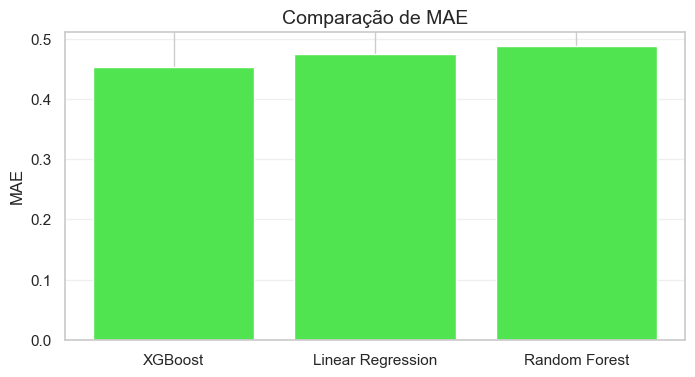

In [13]:
plt.figure(figsize=(8,4))

plt.bar(
    results_df['Model'],
    results_df['MAE'],
    color=PRIMARY_COLOR
)

plt.title('Comparação de MAE')

plt.ylabel('MAE')

plt.grid(axis='y', alpha=0.3)

plt.show()

## 13. Comparação Real vs Predição

In [14]:
best_model_name = results_df.iloc[0]['Model']

best_predictions = predictions_dict[best_model_name]

print(f'Melhor modelo: {best_model_name}')

Melhor modelo: XGBoost


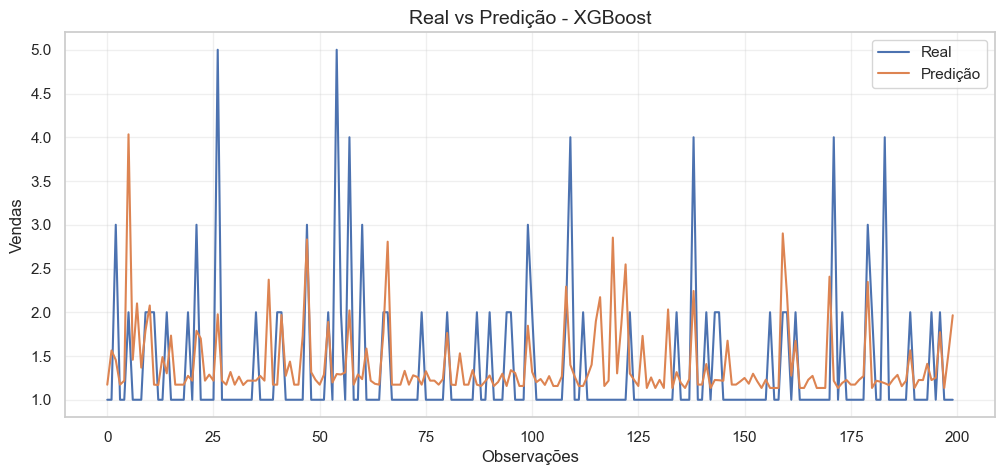

In [15]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values[:200],
    label='Real'
)

plt.plot(
    best_predictions[:200],
    label='Predição'
)

plt.title(f'Real vs Predição - {best_model_name}')

plt.xlabel('Observações')

plt.ylabel('Vendas')

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## 14. Feature Importance

A análise de importância permite identificar quais variáveis possuem maior impacto na previsão da demanda.

In [16]:
best_model = models[best_model_name]

In [17]:
if hasattr(best_model, 'feature_importances_'):

    importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': best_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        'Importance',
        ascending=False
    )

    importance_df

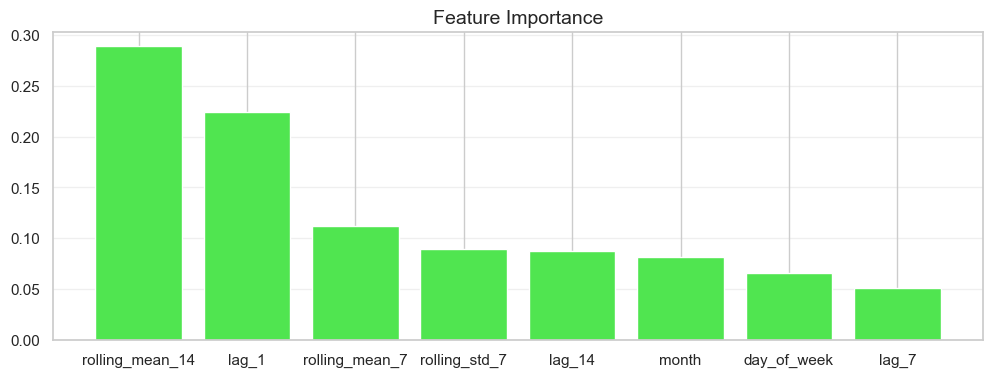

In [18]:
if hasattr(best_model, 'feature_importances_'):

    plt.figure(figsize=(12,4))

    plt.bar(
        importance_df['Feature'],
        importance_df['Importance'],
        color=PRIMARY_COLOR
    )

    plt.title('Feature Importance')

    plt.xticks(rotation=0)

    plt.grid(axis='y', alpha=0.3)

    plt.show()

## 15. Salvando Resultados

In [19]:
forecast_df = test.copy()

forecast_df['prediction'] = best_predictions

In [20]:
forecast_df.to_parquet(
    '../data/processed/df_forecast.parquet'
)

## 16. Insights


O modelo XGBoost apresentou o melhor desempenho entre os algoritmos avaliados, obtendo menor erro médio absoluto (MAE) e melhor capacidade preditiva geral.

Entretanto, o baixo valor de R² indica que a demanda apresenta alta variabilidade e comportamento intermitente, característica comum em problemas reais de supply chain e previsão de estoque.

Esse comportamento sugere:
- vendas irregulares
- baixa previsibilidade temporal
- presença de ruído e sazonalidade não capturada

Apesar disso, os modelos conseguem gerar previsões úteis para apoio à decisão de estoque e reposição.


💡 Insights

A comparação entre modelos permitiu identificar diferentes capacidades preditivas para o problema de demanda.

As features históricas (lags e médias móveis) apresentaram forte relevância, indicando alta dependência temporal nas vendas.

Modelos baseados em árvores demonstraram maior capacidade de capturar relações não lineares e padrões complexos da demanda.



## 17. Conclusão

O benchmark de modelos permitiu identificar a abordagem mais adequada para previsão de demanda no contexto do projeto.

Os resultados obtidos servirão como base para a próxima etapa:
- cálculo de estoque inteligente
- ponto de reposição
- apoio à decisão de compra
- otimização de supply chain